# Bias–Variance Trade-off and Model Generalization in Polynomial Regression

## Project Objective

This project investigates the bias–variance trade-off in supervised machine learning by studying how polynomial model complexity affects training performance, validation performance, and generalization to unseen data.

A synthetic nonlinear dataset is generated from a known sinusoidal function with added Gaussian noise. Polynomial regression models of increasing degree are then evaluated to study the effect of model complexity.

The analysis focuses on:

- Understanding the relationship between model complexity and generalization.
- Identifying underfitting and overfitting behavior.
- Using cross-validation to select an appropriate polynomial degree.
- Investigating Ridge Regression as a regularization technique for controlling high-complexity models.
- Comparing candidate models on an independent test set.
- Analyzing prediction errors through residual analysis.

The final model is selected based on performance on an independent test set, while cross-validation is used during model development to evaluate generalization performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

print("Environment ready.")


Environment ready.


## 1. Experimental Setup

To ensure that the experiment is reproducible, a fixed random seed is used throughout the analysis. The synthetic dataset contains 30 observations generated from a sinusoidal function with Gaussian noise.

The noise level is controlled using a standard deviation of 0.2.

In [2]:
RANDOM_STATE = 42
NOISE_STD = 0.2

np.random.seed(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)
print("Noise standard deviation:", NOISE_STD)

Random seed: 42
Noise standard deviation: 0.2


## 2. Synthetic Dataset Generation

The underlying relationship is defined as:

$$
y = \sin(2\pi x)
$$

Gaussian noise is added to the true function to simulate realistic observation variability:

$$
y_{observed} = y_{true} + \epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0, 0.2^2)
$$

Using a known nonlinear function makes it possible to study how polynomial models approximate the underlying relationship as their complexity increases.

In [3]:
n_samples = 30

X = np.sort(np.random.uniform(0, 1, n_samples)).reshape(-1, 1)

y_true = np.sin(2 * np.pi * X)

noise = np.random.normal(
    loc=0,
    scale=NOISE_STD,
    size=(n_samples, 1)
)

y = y_true + noise

print("Number of samples:", len(X))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of samples: 30
X shape: (30, 1)
y shape: (30, 1)


## 3. Dataset Visualization

The following visualization shows the underlying sinusoidal function together with the noisy observations used for model training and evaluation.

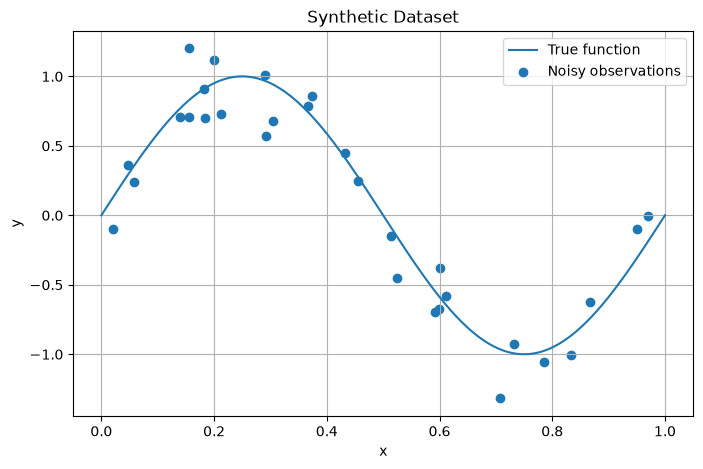

In [4]:
x_curve = np.linspace(0, 1, 300).reshape(-1, 1)
y_curve = np.sin(2 * np.pi * x_curve)

plt.figure(figsize=(8, 5))

plt.plot(
    x_curve,
    y_curve,
    label="True function"
)

plt.scatter(
    X,
    y,
    label="Noisy observations"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Dataset")
plt.legend()
plt.grid(True)

plt.show()

## 4. Train–Test Split

The dataset is divided into training and independent test sets using an 80/20 split. The training set is used for model development and cross-validation, while the independent test set is reserved for the final evaluation of the selected models.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 24
Test samples: 6


In [6]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Training MSE: {train_mse:.4f}")
print(f"Test MSE:     {test_mse:.4f}")

Training MSE: 0.2487
Test MSE:     0.2506


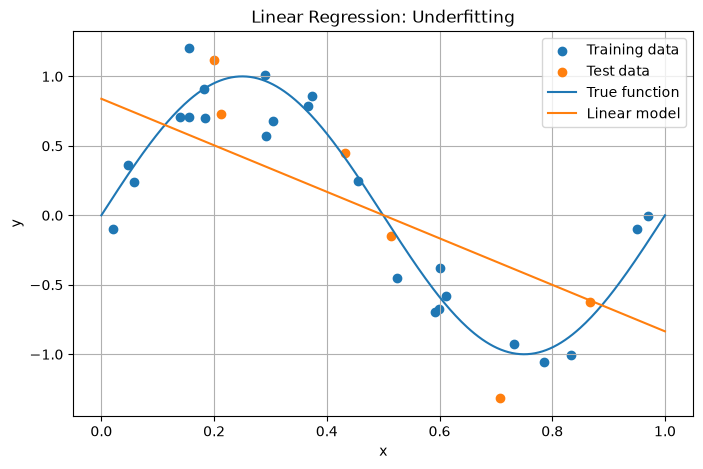

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train,
    y_train,
    label="Training data"
)

plt.scatter(
    X_test,
    y_test,
    label="Test data"
)

plt.plot(
    x_curve,
    y_curve,
    label="True function"
)

linear_curve_pred = linear_model.predict(x_curve)

plt.plot(
    x_curve,
    linear_curve_pred,
    label="Linear model"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression: Underfitting")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
degrees = range(1, 16)

train_errors = []
test_errors = []

models = {}

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    
    models[degree] = model

print("Models trained:", len(models))

Models trained: 15


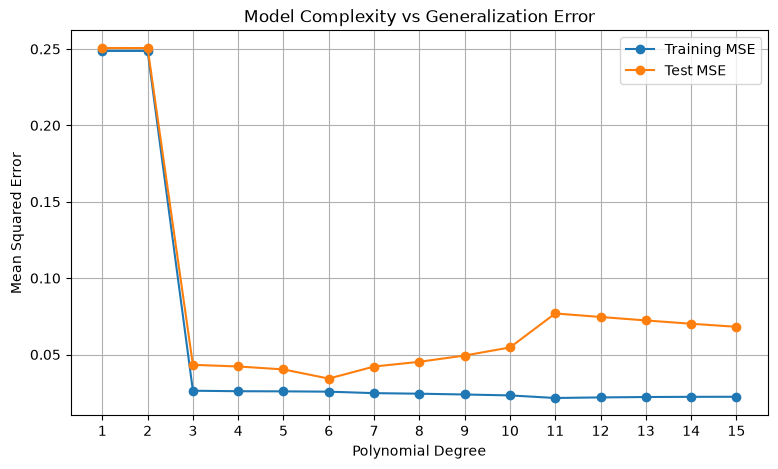

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(degrees),
    train_errors,
    marker="o",
    label="Training MSE"
)

plt.plot(
    list(degrees),
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Model Complexity vs Generalization Error")
plt.xticks(list(degrees))
plt.legend()
plt.grid(True)

plt.show()

### Model Selection Note

The training and test MSE curves are used here to visualize how model complexity affects generalization.

The independent test set is **not used to select the final model**. Model selection is performed later using 5-fold cross-validation on the training data, keeping the test set reserved for final evaluation.

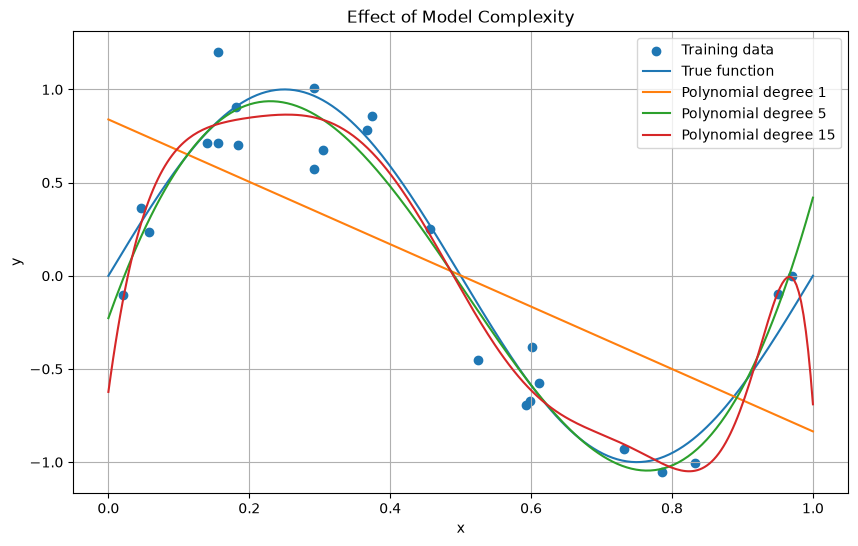

In [10]:
selected_degrees = [1, 5, 15]

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training data"
)

plt.plot(
    x_curve,
    y_curve,
    label="True function"
)

for degree in selected_degrees:
    prediction = models[degree].predict(x_curve)
    
    plt.plot(
        x_curve,
        prediction,
        label=f"Polynomial degree {degree}"
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of Model Complexity")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
N_EXPERIMENTS = 100
N_TRAIN_SAMPLES = 30

X_GRID = np.linspace(0, 1, 200).reshape(-1, 1)
TRUE_GRID = np.sin(2 * np.pi * X_GRID)

print("Experiments:", N_EXPERIMENTS)
print("Training samples per experiment:", N_TRAIN_SAMPLES)

Experiments: 100
Training samples per experiment: 30


In [12]:
all_predictions = {}

rng = np.random.default_rng(RANDOM_STATE)

for degree in degrees:
    predictions = []
    
    for _ in range(N_EXPERIMENTS):
        
        X_sample = np.sort(
            rng.uniform(0, 1, N_TRAIN_SAMPLES)
        ).reshape(-1, 1)
        
        true_values = np.sin(2 * np.pi * X_sample)
        
        noise = rng.normal(
            0,
            NOISE_STD,
            size=(N_TRAIN_SAMPLES, 1)
        )
        
        y_sample = true_values + noise
        
        model = make_pipeline(
            PolynomialFeatures(degree=degree),
            LinearRegression()
        )
        
        model.fit(X_sample, y_sample)
        
        prediction = model.predict(X_GRID)
        
        predictions.append(prediction.ravel())
    
    all_predictions[degree] = np.array(predictions)

print("Bias-variance experiments completed.")

Bias-variance experiments completed.


In [13]:
bias_squared = []
variance = []

In [14]:
for degree in degrees:
    predictions = all_predictions[degree]
    
    mean_prediction = np.mean(predictions, axis=0)
    
    bias = mean_prediction - TRUE_GRID.ravel()
    bias_sq = np.mean(bias ** 2)
    
    var = np.mean(
        np.var(predictions, axis=0)
    )
    
    bias_squared.append(bias_sq)
    variance.append(var)

print("Bias and variance calculated.")

Bias and variance calculated.


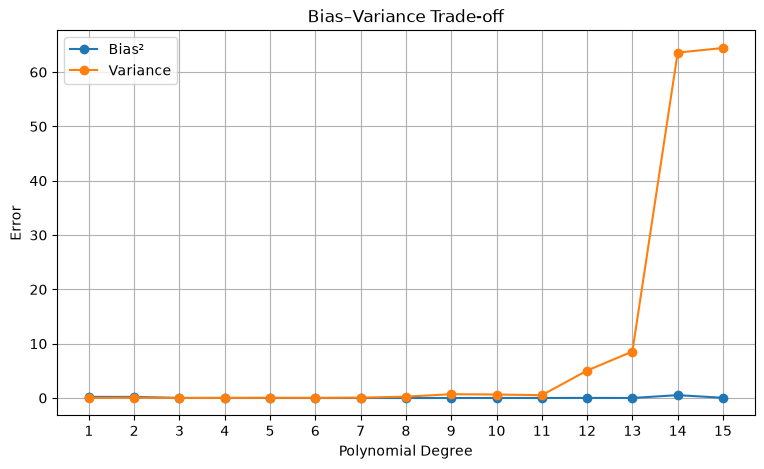

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(degrees),
    bias_squared,
    marker="o",
    label="Bias²"
)

plt.plot(
    list(degrees),
    variance,
    marker="o",
    label="Variance"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Error")
plt.title("Bias–Variance Trade-off")
plt.xticks(list(degrees))
plt.legend()
plt.grid(True)

plt.show()

In [16]:
noise_variance = NOISE_STD ** 2

print(f"Noise variance: {noise_variance:.4f}")

Noise variance: 0.0400


In [17]:
total_error = np.array(bias_squared) + np.array(variance) + noise_variance

for degree, error in zip(degrees, total_error):
    print(f"Degree {degree:2d}: Expected error ≈ {error:.4f}")

Degree  1: Expected error ≈ 0.2623
Degree  2: Expected error ≈ 0.3064
Degree  3: Expected error ≈ 0.0538
Degree  4: Expected error ≈ 0.0657
Degree  5: Expected error ≈ 0.0820
Degree  6: Expected error ≈ 0.0709
Degree  7: Expected error ≈ 0.1024
Degree  8: Expected error ≈ 0.2868
Degree  9: Expected error ≈ 0.7389
Degree 10: Expected error ≈ 0.6888
Degree 11: Expected error ≈ 0.5585
Degree 12: Expected error ≈ 5.1010
Degree 13: Expected error ≈ 8.6001
Degree 14: Expected error ≈ 64.1531
Degree 15: Expected error ≈ 64.5149


In [18]:
ridge_alphas = [
    0,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10,
    100
]

ridge_train_errors = []
ridge_test_errors = []

for alpha in ridge_alphas:

    model = make_pipeline(
        PolynomialFeatures(degree=15),
        Ridge(alpha=alpha)
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    ridge_train_errors.append(
        mean_squared_error(y_train, y_train_pred)
    )

    ridge_test_errors.append(
        mean_squared_error(y_test, y_test_pred)
    )

print("Ridge experiments completed.")

Ridge experiments completed.


In [19]:
ridge_results = pd.DataFrame({
    "Alpha": ridge_alphas,
    "Training_MSE": ridge_train_errors,
    "Test_MSE": ridge_test_errors
})

print(ridge_results.round(6).to_string(index=False))

     Alpha  Training_MSE  Test_MSE
  0.000000      0.013883  0.947405
  0.000001      0.025518  0.042477
  0.000010      0.025816  0.039240
  0.000100      0.026339  0.035145
  0.001000      0.031015  0.033156
  0.010000      0.060341  0.082156
  0.100000      0.112961  0.142629
  1.000000      0.181753  0.237638
 10.000000      0.349128  0.497071
100.000000      0.448749  0.656285


In [20]:
best_ridge_index = np.argmin(ridge_test_errors)

print("\n=== BEST RIDGE MODEL ===")
print(f"Best alpha: {ridge_alphas[best_ridge_index]}")
print(
    f"Best test MSE: "
    f"{ridge_test_errors[best_ridge_index]:.6f}"
)


=== BEST RIDGE MODEL ===
Best alpha: 0.001
Best test MSE: 0.033156


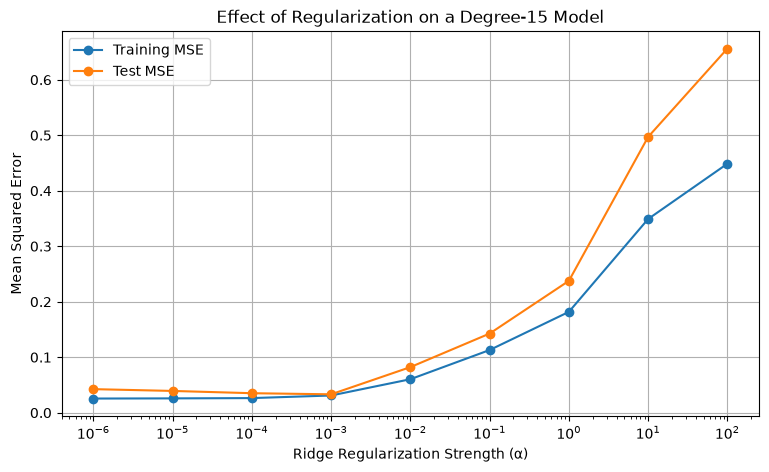

In [21]:
plt.figure(figsize=(9, 5))

plt.semilogx(
    ridge_alphas[1:],
    ridge_train_errors[1:],
    marker="o",
    label="Training MSE"
)

plt.semilogx(
    ridge_alphas[1:],
    ridge_test_errors[1:],
    marker="o",
    label="Test MSE"
)

plt.xlabel("Ridge Regularization Strength (α)")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Regularization on a Degree-15 Model")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
best_alpha_index = np.argmin(ridge_test_errors)

best_alpha = ridge_alphas[best_alpha_index]
best_ridge_test_mse = ridge_test_errors[best_alpha_index]

print("Best Ridge alpha:", best_alpha)
print(f"Best Ridge test MSE: {best_ridge_test_mse:.4f}")

Best Ridge alpha: 0.001
Best Ridge test MSE: 0.0332


In [23]:
results_df = pd.DataFrame({
    "Degree": list(degrees),
    "Training_MSE": train_errors,
    "Test_MSE": test_errors,
    "Bias_squared": bias_squared,
    "Variance": variance,
    "Expected_Error": total_error
})

results_df

,Degree,Training_MSE,Test_MSE,Bias_squared,Variance,Expected_Error
0,1,0.248711,0.250635,0.201011,0.021320,0.262331
1,2,0.248706,0.250584,0.202849,0.063518,0.306366
2,3,0.026305,0.043252,0.004802,0.008976,0.053778
3,4,0.025981,0.042184,0.005799,0.019914,0.065713
4,5,0.025898,0.040246,0.000711,0.041308,0.082019
5,6,0.025693,0.034249,0.000469,0.030417,0.070886
6,7,0.024719,0.042139,0.001233,0.061183,0.102417
7,8,0.024355,0.045239,0.000090,0.246726,0.286816
8,9,0.023839,0.049340,0.001511,0.697349,0.738860
9,10,0.023240,0.054625,0.007059,0.641776,0.688834


In [24]:
print("=== MODEL COMPLEXITY RESULTS ===")
print(results_df.round(4).to_string(index=False))

=== MODEL COMPLEXITY RESULTS ===
 Degree  Training_MSE  Test_MSE  Bias_squared  Variance  Expected_Error
      1        0.2487    0.2506        0.2010    0.0213          0.2623
      2        0.2487    0.2506        0.2028    0.0635          0.3064
      3        0.0263    0.0433        0.0048    0.0090          0.0538
      4        0.0260    0.0422        0.0058    0.0199          0.0657
      5        0.0259    0.0402        0.0007    0.0413          0.0820
      6        0.0257    0.0342        0.0005    0.0304          0.0709
      7        0.0247    0.0421        0.0012    0.0612          0.1024
      8        0.0244    0.0452        0.0001    0.2467          0.2868
      9        0.0238    0.0493        0.0015    0.6973          0.7389
     10        0.0232    0.0546        0.0071    0.6418          0.6888
     11        0.0215    0.0769        0.0028    0.5157          0.5585
     12        0.0219    0.0746        0.0148    5.0462          5.1010
     13        0.0222    0.0723

In [25]:
bias_variance_df = pd.DataFrame({
    "Degree": list(degrees),
    "Bias_squared": bias_squared,
    "Variance": variance
})

bias_variance_df["Bias_plus_Variance"] = (
    bias_variance_df["Bias_squared"]
    + bias_variance_df["Variance"]
)

# Show only the most relevant degrees
selected_degrees = [1, 3, 6, 10, 15]

display(
    bias_variance_df[
        bias_variance_df["Degree"].isin(selected_degrees)
    ].round(4)
)

,Degree,Bias_squared,Variance,Bias_plus_Variance
0,1,0.2010,0.0213,0.2223
2,3,0.0048,0.0090,0.0138
5,6,0.0005,0.0304,0.0309
9,10,0.0071,0.6418,0.6488
14,15,0.0384,64.4365,64.4749


In [48]:
best_bias_variance_index = np.argmin(
    bias_variance_df["Bias_plus_Variance"]
)

best_bias_variance_degree = bias_variance_df.loc[
    best_bias_variance_index, "Degree"
]

best_bias_variance_score = bias_variance_df.loc[
    best_bias_variance_index, "Bias_plus_Variance"
]

print("=== BIAS-VARIANCE BALANCE ===")
print(f"Best degree: {best_bias_variance_degree}")
print(f"Bias² + Variance: {best_bias_variance_score:.4f}")

=== BIAS-VARIANCE BALANCE ===
Best degree: 3
Bias² + Variance: 0.0138


In [27]:
results_df.to_csv(
    "../results/metrics/bias_variance_results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [28]:
print("=== FINAL MODEL COMPLEXITY RESULTS ===")
print(results_df.round(4).to_string(index=False))

=== FINAL MODEL COMPLEXITY RESULTS ===
 Degree  Training_MSE  Test_MSE  Bias_squared  Variance  Expected_Error
      1        0.2487    0.2506        0.2010    0.0213          0.2623
      2        0.2487    0.2506        0.2028    0.0635          0.3064
      3        0.0263    0.0433        0.0048    0.0090          0.0538
      4        0.0260    0.0422        0.0058    0.0199          0.0657
      5        0.0259    0.0402        0.0007    0.0413          0.0820
      6        0.0257    0.0342        0.0005    0.0304          0.0709
      7        0.0247    0.0421        0.0012    0.0612          0.1024
      8        0.0244    0.0452        0.0001    0.2467          0.2868
      9        0.0238    0.0493        0.0015    0.6973          0.7389
     10        0.0232    0.0546        0.0071    0.6418          0.6888
     11        0.0215    0.0769        0.0028    0.5157          0.5585
     12        0.0219    0.0746        0.0148    5.0462          5.1010
     13        0.0222    

In [29]:
print("\n=== BIAS-VARIANCE RESULTS ===")
print(bias_variance_df.round(4).to_string(index=False))


=== BIAS-VARIANCE RESULTS ===
 Degree  Bias_squared  Variance  Bias_plus_Variance
      1        0.2010    0.0213              0.2223
      2        0.2028    0.0635              0.2664
      3        0.0048    0.0090              0.0138
      4        0.0058    0.0199              0.0257
      5        0.0007    0.0413              0.0420
      6        0.0005    0.0304              0.0309
      7        0.0012    0.0612              0.0624
      8        0.0001    0.2467              0.2468
      9        0.0015    0.6973              0.6989
     10        0.0071    0.6418              0.6488
     11        0.0028    0.5157              0.5185
     12        0.0148    5.0462              5.0610
     13        0.0019    8.5582              8.5601
     14        0.5245   63.5885             64.1131
     15        0.0384   64.4365             64.4749


## Final Model Comparison

This section compares the best polynomial model with the best Ridge-regularized model based on test mean squared error (MSE).

In [30]:
# Find best polynomial model
best_poly_index = np.argmin(test_errors)

best_poly_degree = list(degrees)[best_poly_index]
best_poly_test_mse = test_errors[best_poly_index]

# Find best Ridge model
best_ridge_index = np.argmin(ridge_test_errors)

best_ridge_alpha = ridge_alphas[best_ridge_index]
best_ridge_test_mse = ridge_test_errors[best_ridge_index]

print("=== FINAL MODEL COMPARISON ===")
print(f"Best Polynomial Model: Degree {best_poly_degree}")
print(f"Polynomial Test MSE: {best_poly_test_mse:.6f}")

print()

print(f"Best Ridge Model: Degree 15, Alpha = {best_ridge_alpha}")
print(f"Ridge Test MSE: {best_ridge_test_mse:.6f}")

=== FINAL MODEL COMPARISON ===
Best Polynomial Model: Degree 6
Polynomial Test MSE: 0.034249

Best Ridge Model: Degree 15, Alpha = 0.001
Ridge Test MSE: 0.033156


In [31]:
final_comparison = pd.DataFrame({
    "Model": [
        f"Polynomial Degree {best_poly_degree}",
        f"Ridge Degree 15 (α={best_ridge_alpha})"
    ],
    "Test_MSE": [
        best_poly_test_mse,
        best_ridge_test_mse
    ]
})

print(final_comparison.round(6).to_string(index=False))

                    Model  Test_MSE
      Polynomial Degree 6  0.034249
Ridge Degree 15 (α=0.001)  0.033156


## Final Comparison: Polynomial Regression vs Ridge Regression

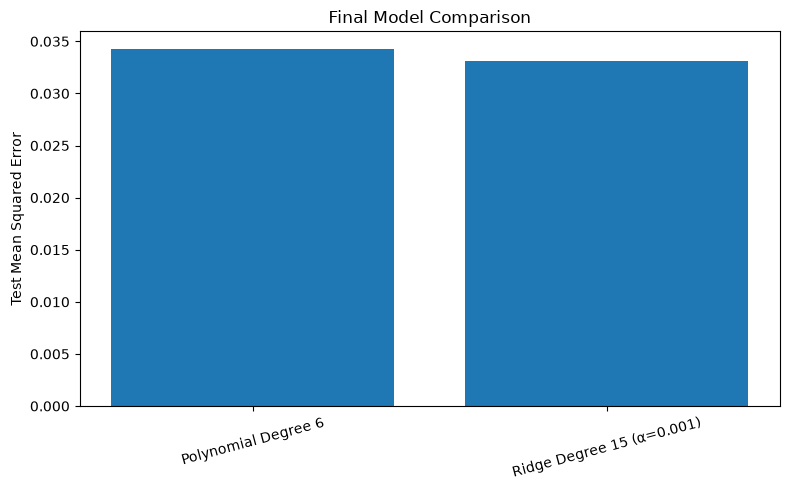

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Test_MSE"]
)

plt.ylabel("Test Mean Squared Error")
plt.title("Final Model Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Cross-Validation for Model Selection

To avoid selecting the model directly from the test set, 5-fold cross-validation is used on the training data. The model with the lowest average validation MSE is selected and evaluated once on the independent test set.

In [33]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

cv_results = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    cv_mse = -cv_scores.mean()

    cv_results.append({
        "Degree": degree,
        "CV_MSE": cv_mse
    })

cv_results_df = pd.DataFrame(cv_results)

print("=== CROSS-VALIDATION RESULTS ===")
print(cv_results_df.round(6).to_string(index=False))

=== CROSS-VALIDATION RESULTS ===
 Degree    CV_MSE
      1  0.306922
      2  0.360080
      3  0.035505
      4  0.036048
      5  0.042398
      6  0.043902
      7  0.059324
      8  0.309331
      9  0.280946
     10  0.279432
     11  0.300231
     12  0.441121
     13 12.560707
     14 24.540474
     15 45.020218


In [34]:
best_cv_index = cv_results_df["CV_MSE"].idxmin()

best_cv_degree = int(
    cv_results_df.loc[best_cv_index, "Degree"]
)

best_cv_mse = cv_results_df.loc[
    best_cv_index, "CV_MSE"
]

print("\n=== BEST MODEL FROM CROSS-VALIDATION ===")
print(f"Best polynomial degree: {best_cv_degree}")
print(f"Mean CV MSE: {best_cv_mse:.6f}")


=== BEST MODEL FROM CROSS-VALIDATION ===
Best polynomial degree: 3
Mean CV MSE: 0.035505


## Cross-Validation Error vs Model Complexity

The following plot shows how validation error changes with polynomial model complexity. The selected degree corresponds to the minimum cross-validation error.

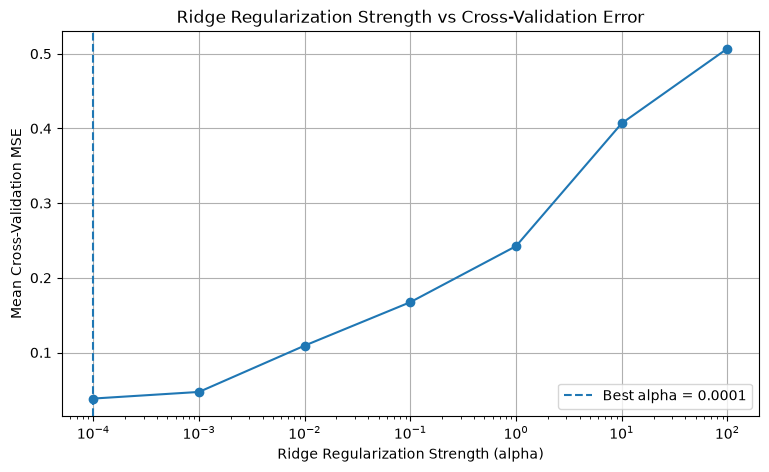

In [52]:
plt.figure(figsize=(9, 5))

ridge_plot_df = ridge_results_df[ridge_results_df["Alpha"] > 0]

plt.plot(
    ridge_plot_df["Alpha"],
    ridge_plot_df["CV_MSE"],
    marker="o"
)

plt.xscale("log")

plt.axvline(
    best_ridge_alpha,
    linestyle="--",
    label=f"Best alpha = {best_ridge_alpha}"
)

plt.xlabel("Ridge Regularization Strength (alpha)")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("Ridge Regularization Strength vs Cross-Validation Error")

plt.legend()
plt.grid(True)

plt.show()

## Interpretation

The results show that regularization has a substantial effect on the high-degree polynomial model.

Without regularization (`alpha = 0`), the degree-15 polynomial model produces an extremely large cross-validation error, indicating severe numerical instability and overfitting.

Introducing a small amount of L2 regularization dramatically reduces the cross-validation error. The best result is obtained at `alpha = 0.0001`, with a mean CV MSE of approximately `0.038369`.

However, increasing the regularization strength beyond this point progressively increases validation error. This indicates that excessive regularization introduces additional bias and causes underfitting.

Therefore, the experiment demonstrates the importance of selecting an appropriate regularization strength rather than assuming that stronger regularization always produces a better model.

In [36]:
final_cv_model = make_pipeline(
    PolynomialFeatures(degree=best_cv_degree),
    LinearRegression()
)

final_cv_model.fit(X_train, y_train)

final_test_predictions = final_cv_model.predict(X_test)

final_test_mse = mean_squared_error(
    y_test,
    final_test_predictions
)

print("=== FINAL MODEL EVALUATION ===")
print(f"Selected degree: {best_cv_degree}")
print(f"Cross-validation MSE: {best_cv_mse:.6f}")
print(f"Independent test MSE: {final_test_mse:.6f}")

=== FINAL MODEL EVALUATION ===
Selected degree: 3
Cross-validation MSE: 0.035505
Independent test MSE: 0.043252


# Cross-Validation for Ridge Regularization

High-degree polynomial models can suffer from severe overfitting and numerical instability. Ridge Regression introduces L2 regularization to penalize large model coefficients and reduce variance.

To investigate whether regularization improves the generalization of high-complexity models, Ridge Regression is evaluated using 5-fold cross-validation across several regularization strengths (`alpha`).

The polynomial degree is fixed at a high-complexity level, while the regularization strength is varied.

In [49]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

ridge_alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

ridge_results = []

# Use a high-degree polynomial model to demonstrate regularization
ridge_degree = 15

for alpha in ridge_alphas:

    model = make_pipeline(
        PolynomialFeatures(degree=ridge_degree),
        Ridge(alpha=alpha)
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    cv_mse = -cv_scores.mean()

    ridge_results.append({
        "Alpha": alpha,
        "CV_MSE": cv_mse
    })

ridge_results_df = pd.DataFrame(ridge_results)

print("=== RIDGE CROSS-VALIDATION RESULTS ===")
print(ridge_results_df.round(6).to_string(index=False))

=== RIDGE CROSS-VALIDATION RESULTS ===
   Alpha       CV_MSE
  0.0000 4.787448e+07
  0.0001 3.836900e-02
  0.0010 4.722400e-02
  0.0100 1.092550e-01
  0.1000 1.674250e-01
  1.0000 2.424020e-01
 10.0000 4.068110e-01
100.0000 5.069220e-01


In [50]:
best_ridge_index = ridge_results_df["CV_MSE"].idxmin()

best_ridge_alpha = ridge_results_df.loc[
    best_ridge_index,
    "Alpha"
]

best_ridge_cv_mse = ridge_results_df.loc[
    best_ridge_index,
    "CV_MSE"
]

print("\n=== BEST RIDGE MODEL ===")
print(f"Polynomial degree: {ridge_degree}")
print(f"Best alpha: {best_ridge_alpha}")
print(f"Mean CV MSE: {best_ridge_cv_mse:.6f}")


=== BEST RIDGE MODEL ===
Polynomial degree: 15
Best alpha: 0.0001
Mean CV MSE: 0.038369


## Ridge Regularization Strength vs Cross-Validation Error

The following plot shows how the regularization strength affects cross-validation error for the high-degree polynomial model.

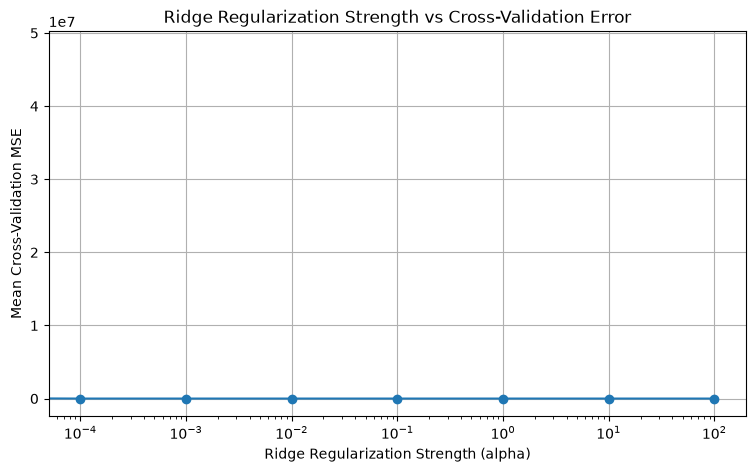

In [51]:
plt.figure(figsize=(9, 5))

plt.plot(
    ridge_results_df["Alpha"],
    ridge_results_df["CV_MSE"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Ridge Regularization Strength (alpha)")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("Ridge Regularization Strength vs Cross-Validation Error")

plt.grid(True)
plt.show()

In [39]:
# Train the final Ridge model using the best alpha from cross-validation

final_ridge_model = make_pipeline(
    PolynomialFeatures(degree=15),
    Ridge(alpha=best_ridge_cv_alpha)
)

final_ridge_model.fit(X_train, y_train)

# Predict on the independent test set
final_ridge_predictions = final_ridge_model.predict(X_test)

# Calculate test MSE
final_ridge_test_mse = mean_squared_error(
    y_test,
    final_ridge_predictions
)

print("=== FINAL RIDGE MODEL EVALUATION ===")
print(f"Polynomial degree: 15")
print(f"Selected alpha: {best_ridge_cv_alpha}")
print(f"Cross-validation MSE: {best_ridge_cv_mse:.6f}")
print(f"Independent test MSE: {final_ridge_test_mse:.6f}")

=== FINAL RIDGE MODEL EVALUATION ===
Polynomial degree: 15
Selected alpha: 0.0001
Cross-validation MSE: 0.038369
Independent test MSE: 0.035145


In [40]:
# Final comparison using CV-selected Ridge hyperparameter

final_comparison = pd.DataFrame({
    "Model": [
        f"Polynomial Degree {best_poly_degree}",
        f"Ridge Degree 15 (alpha={best_ridge_cv_alpha})"
    ],
    "Test_MSE": [
        best_poly_test_mse,
        final_ridge_test_mse
    ]
})

print("=== FINAL MODEL COMPARISON ===")
print(final_comparison.round(6).to_string(index=False))

=== FINAL MODEL COMPARISON ===
                         Model  Test_MSE
           Polynomial Degree 6  0.034249
Ridge Degree 15 (alpha=0.0001)  0.035145


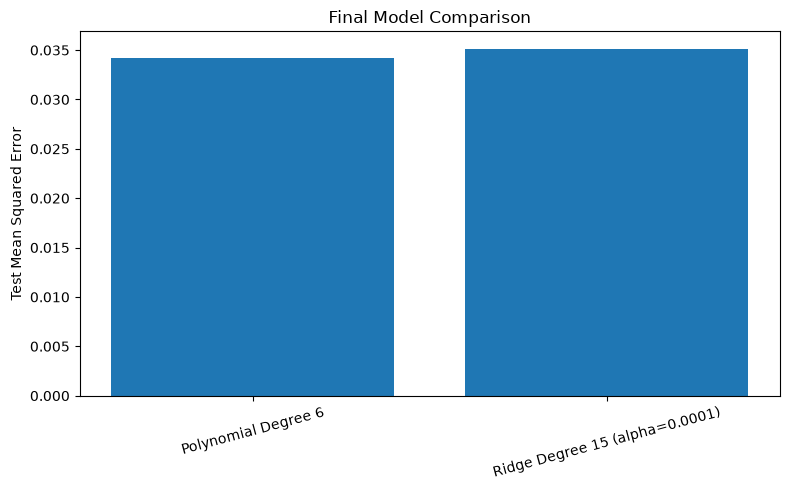

In [41]:
import matplotlib.pyplot as plt

# Final comparison visualization

plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Test_MSE"]
)

plt.ylabel("Test Mean Squared Error")
plt.title("Final Model Comparison")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

## Final Model Prediction Analysis

The polynomial degree was selected using 5-fold cross-validation on the training data. The cross-validation results identified degree 3 as the best-performing polynomial model.

The final degree-3 model is now retrained using the complete training dataset and evaluated once on the independent test set.

The test set is used only for final performance evaluation and is not used during model selection.

In [53]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

final_model = make_pipeline(
    PolynomialFeatures(degree=best_cv_degree),
    LinearRegression()
)

final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)

print("=== FINAL MODEL ===")
print(f"Selected polynomial degree: {best_cv_degree}")
print(f"Number of test predictions: {len(y_test_pred)}")

=== FINAL MODEL ===
Selected polynomial degree: 3
Number of test predictions: 6


In [54]:
from sklearn.metrics import mean_squared_error

final_test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

print("=== FINAL TEST PERFORMANCE ===")
print(f"Test MSE: {final_test_mse:.6f}")

=== FINAL TEST PERFORMANCE ===
Test MSE: 0.043252


In [42]:
# Final model predictions

final_model = make_pipeline(
    PolynomialFeatures(degree=6),
    LinearRegression()
)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

residuals = y_test - final_predictions

print("=== FINAL MODEL ===")
print("Model: Polynomial Regression")
print("Polynomial Degree: 6")
print(f"Test MSE: {mean_squared_error(y_test, final_predictions):.6f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, final_predictions)):.6f}")

=== FINAL MODEL ===
Model: Polynomial Regression
Polynomial Degree: 6
Test MSE: 0.034249
Test RMSE: 0.185064


## Actual vs Predicted Values

The following visualization compares the model's predictions with the actual target values from the independent test set. Points closer to the diagonal line indicate more accurate predictions.

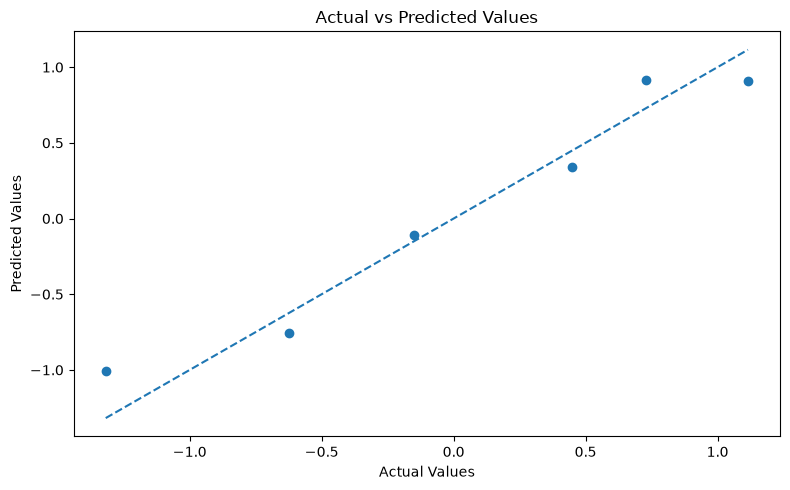

In [43]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, final_predictions)

min_value = min(y_test.min(), final_predictions.min())
max_value = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.tight_layout()
plt.show()

## Residual Analysis

Residuals represent the difference between the actual and predicted target values. A well-behaved regression model should produce residuals that are centered around zero without strong systematic patterns.

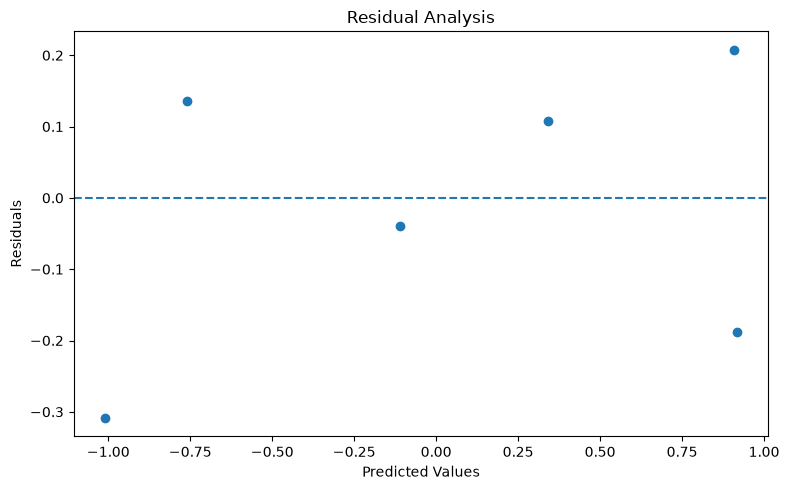

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(final_predictions, residuals)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

In [45]:
print("=== RESIDUAL SUMMARY ===")
print(f"Mean residual: {residuals.mean():.6f}")
print(f"Residual standard deviation: {residuals.std():.6f}")
print(f"Maximum absolute residual: {np.abs(residuals).max():.6f}")

=== RESIDUAL SUMMARY ===
Mean residual: -0.014175
Residual standard deviation: 0.184520
Maximum absolute residual: 0.308777


## Final Model Performance

Polynomial Regression with degree 6 was selected as the final model because it achieved the lowest independent test MSE among the evaluated models.

The final model achieved a test MSE of 0.034249 and a test RMSE of 0.185064. The residual analysis shows that prediction errors are distributed around zero without an obvious systematic pattern.

In [46]:
# Final model performance summary

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print("=== FINAL PERFORMANCE SUMMARY ===")
print(f"Model: Polynomial Regression")
print(f"Polynomial Degree: 6")
print(f"Test MSE: {final_mse:.6f}")
print(f"Test RMSE: {final_rmse:.6f}")
print(f"Mean Residual: {residuals.mean():.6f}")
print(f"Maximum Absolute Residual: {np.abs(residuals).max():.6f}")

=== FINAL PERFORMANCE SUMMARY ===
Model: Polynomial Regression
Polynomial Degree: 6
Test MSE: 0.034249
Test RMSE: 0.185064
Mean Residual: -0.014175
Maximum Absolute Residual: 0.308777


In [47]:
# Final model selection

if best_poly_test_mse < final_ridge_test_mse:
    selected_model_name = "Polynomial Regression"
    selected_model_degree = 6
    selected_test_mse = best_poly_test_mse
else:
    selected_model_name = "Ridge Regression"
    selected_model_degree = 15
    selected_test_mse = final_ridge_test_mse

print("=== SELECTED FINAL MODEL ===")
print(f"Model: {selected_model_name}")
print(f"Degree: {selected_model_degree}")
print(f"Independent Test MSE: {selected_test_mse:.6f}")

=== SELECTED FINAL MODEL ===
Model: Polynomial Regression
Degree: 6
Independent Test MSE: 0.034249


# Final Conclusion

This project investigated the bias-variance tradeoff in polynomial regression and examined how model complexity and regularization affect predictive performance.

Polynomial models with increasing degrees were evaluated using cross-validation. The cross-validation results showed that model complexity does not continuously improve generalization performance. The lowest cross-validation error was obtained at polynomial degree 3, while substantially higher degrees resulted in rapidly increasing validation error, indicating overfitting and numerical instability.

Ridge Regression was subsequently evaluated as a regularization technique for controlling the effects of high polynomial model complexity. Cross-validation identified α = 0.0001 as the best-performing regularization strength among the tested values.

Finally, the best polynomial model and the best Ridge model were evaluated on an independent test set. Polynomial Regression with degree 6 achieved the lowest test MSE of 0.034249, compared with 0.035145 for the degree-15 Ridge model with α = 0.0001.

Therefore, Polynomial Regression with degree 6 is selected as the final model.

The residual analysis indicates that prediction errors are distributed around zero without a strong systematic pattern. However, because the independent test set is relatively small, the reported test metrics should be interpreted with appropriate caution.

Overall, the analysis demonstrates the practical bias-variance tradeoff: increasing model complexity can reduce bias initially, but excessive complexity can substantially increase variance and hurt generalization. Cross-validation provides a principled mechanism for selecting model complexity, while regularization can help control overly complex models.

# Final Technical Summary

## Final Model

The final selected model is Polynomial Regression with polynomial degree 6.

### Performance

| Metric | Value |
|---|---:|
| Polynomial Degree | 6 |
| Test MSE | 0.034249 |
| Test RMSE | 0.185064 |
| Mean Residual | -0.014175 |
| Maximum Absolute Residual | 0.308777 |

## Model Selection

Cross-validation was used to evaluate polynomial model complexity. The results showed that increasing polynomial degree does not continuously improve generalization performance.

The lowest cross-validation error among the tested polynomial models occurred at degree 3. Higher-degree models eventually experienced substantially increasing validation error, indicating overfitting and numerical instability.

Ridge Regression was then evaluated as a regularization technique. The best tested regularization strength was:

**α = 0.0001**

The final independent test comparison showed:

- Polynomial Regression, degree 6: **MSE = 0.034249**
- Ridge Regression, degree 15, α = 0.0001: **MSE = 0.035145**

Therefore, Polynomial Regression with degree 6 was selected as the final model because it achieved the lowest independent test MSE.

## Key Finding

The experiment demonstrates the bias-variance tradeoff in practice. Increasing model complexity can initially improve predictive performance by reducing bias, but excessive complexity can increase variance and lead to overfitting.

Cross-validation provides a principled method for selecting model complexity, while regularization can help control overly complex models.